# **Spotify NLP App Review**

# Data Collection

100,000 Spotify reviews scraped directly from the Google Play Store using `google-play-scraper`, rather than a static Kaggle dataset. This keeps app version metadata intact, which matters later for tracking sentiment across releases.

In [65]:
from google_play_scraper import reviews, Sort
import pandas as pd
import os

if os.path.exists("spotify_reviews.csv"):
    df = pd.read_csv("spotify_reviews.csv")
    print("Loaded from CSV")
else:
    result, _ = reviews('com.spotify.music', lang='en', country='us', sort=Sort.NEWEST, count=100000, filter_score_with=None)
    df = pd.DataFrame(result)
    df.to_csv("spotify_reviews.csv", index=False)
    print("Scraped and saved")

Loaded from CSV


In [66]:
print(df.shape)
print(df.columns.tolist())
df.head()

(100000, 11)
['reviewId', 'userName', 'userImage', 'content', 'score', 'thumbsUpCount', 'reviewCreatedVersion', 'at', 'replyContent', 'repliedAt', 'appVersion']


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,d5fc908a-fee8-449c-9c73-e8b42376ff46,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,lot of ads,3,0,9.1.60.1970,2026-07-07 12:25:00,NaN,NaN,9.1.60.1970
1,7df9008d-9b92-4ef3-a820-0f473866d14f,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,"I love it, but DAMN there are a lot of ads. I ...",3,0,9.1.62.1601,2026-07-07 12:10:37,Hi. We'll pass this on to our ads team. Furthe...,2026-07-07 19:15:34,9.1.62.1601
2,1444ab2b-c86b-460f-9a5b-dd34e475f272,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,one of the best music apps I've come across,4,0,NaN,2026-07-07 12:06:56,NaN,NaN,NaN
3,b3e19448-6135-48a9-bb91-1a29b788cb10,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,"One word..... ""Amazing""",5,0,9.1.62.1601,2026-07-07 12:02:01,NaN,NaN,9.1.62.1601
4,edd06181-467d-4885-8abf-b6c3a4904ac6,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,"There may be a couple ads , but overall , it's...",5,0,9.1.62.1601,2026-07-07 11:59:11,NaN,NaN,9.1.62.1601


# Data Cleaning

Dropping columns with no analytical value (`replyContent`, `repliedAt`, `userImage`, `reviewId`, `reviewCreatedVersion`), and the 2 rows with null review text.

In [67]:
# Irrelevant columns
df = df.drop(columns=['replyContent', 'repliedAt', 'userImage', 'reviewId', 'reviewCreatedVersion'])

# Null content
df = df.dropna(subset=['content'])

print(df.shape)
print(df.isnull().sum())

(99998, 6)
userName             0
content              0
score                0
thumbsUpCount        0
at                   0
appVersion       16369
dtype: int64


**Result:** 99,998 reviews remain. `appVersion` still has 16,369 nulls, these are kept for sentiment analysis but excluded later from version-based temporal analysis.

# Exploratory Data Analysis

## Score Distribution

In [68]:
df["score"].value_counts().sort_index()

score
1    23190
2     5065
3     5565
4     9557
5    56621
Name: count, dtype: int64

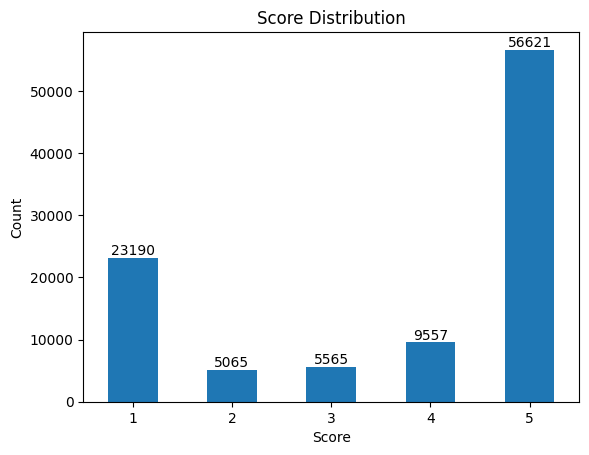

In [104]:
import matplotlib.pyplot as plt

ax = df["score"].value_counts().sort_index().plot(kind = "bar")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

for p in ax.patches:
    ax.annotate(str(int(p.get_height())), (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom')

plt.title("Score Distribution")
plt.xlabel("Score")
plt.ylabel("Count")
plt.show()

**Finding:** heavily skewed toward 5 stars (56.6%), with 1 stars the second largest group (23.2%), the classic bimodal pattern for app store reviews.

In [70]:
df["at"] = pd.to_datetime(df["at"])
df["month"] = df["at"].dt.month
df.head()

,userName,content,score,thumbsUpCount,at,appVersion,month
0,A Google user,lot of ads,3,0,2026-07-07 12:25:00,9.1.60.1970,7
1,A Google user,"I love it, but DAMN there are a lot of ads. I ...",3,0,2026-07-07 12:10:37,9.1.62.1601,7
2,A Google user,one of the best music apps I've come across,4,0,2026-07-07 12:06:56,NaN,7
3,A Google user,"One word..... ""Amazing""",5,0,2026-07-07 12:02:01,9.1.62.1601,7
4,A Google user,"There may be a couple ads , but overall , it's...",5,0,2026-07-07 11:59:11,9.1.62.1601,7


## Reviews Over Time

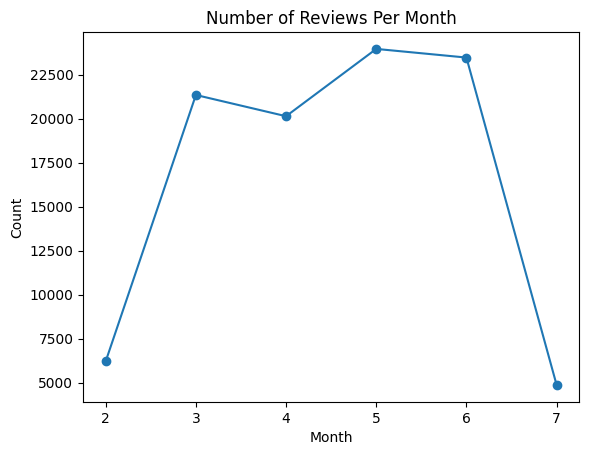

In [71]:
ax2 = df["month"].value_counts().sort_index().plot(kind = "line", marker = 'o')
plt.title("Number of Reviews Per Month")
plt.xlabel("Month")
plt.ylabel("Count")
plt.show()

In [72]:
version_counts = df["appVersion"].value_counts()
valid_versions = version_counts[version_counts >= 150].index
df_filtered = df[df["appVersion"].isin(valid_versions)]

## Reviews Over Versions

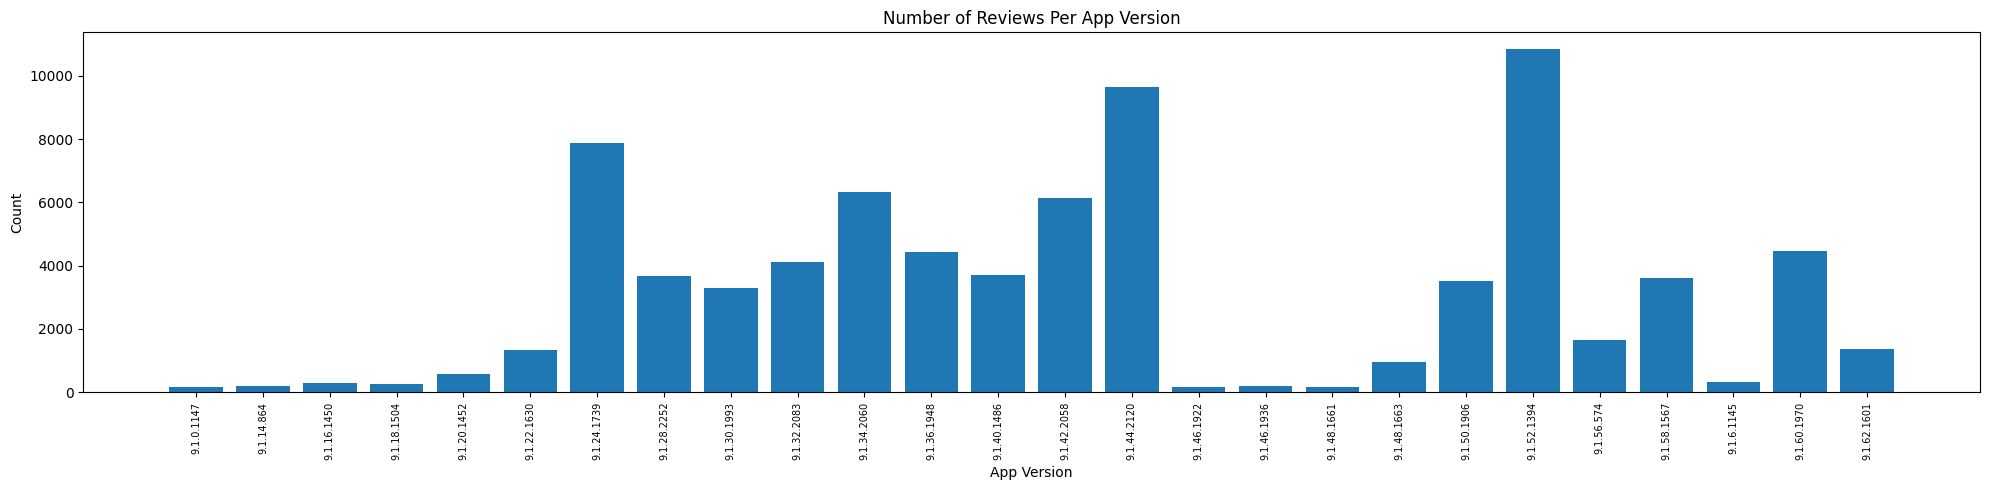

In [73]:
version_counts_filtered = df_filtered["appVersion"].value_counts().sort_index()

fig, ax3 = plt.subplots(figsize=(20, 5))
ax3.bar(range(len(version_counts_filtered)), version_counts_filtered.values)
ax3.set_xticks(range(len(version_counts_filtered)))
ax3.set_xticklabels(version_counts_filtered.index, rotation=90, fontsize=7)
plt.title("Number of Reviews Per App Version")
plt.xlabel("App Version")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## Review Length

In [74]:
df["word_count"] = df["content"].str.split().str.len()
df.head()

,userName,content,score,thumbsUpCount,at,appVersion,month,word_count
0,A Google user,lot of ads,3,0,2026-07-07 12:25:00,9.1.60.1970,7,3
1,A Google user,"I love it, but DAMN there are a lot of ads. I ...",3,0,2026-07-07 12:10:37,9.1.62.1601,7,17
2,A Google user,one of the best music apps I've come across,4,0,2026-07-07 12:06:56,NaN,7,9
3,A Google user,"One word..... ""Amazing""",5,0,2026-07-07 12:02:01,9.1.62.1601,7,3
4,A Google user,"There may be a couple ads , but overall , it's...",5,0,2026-07-07 11:59:11,9.1.62.1601,7,13


<Axes: >

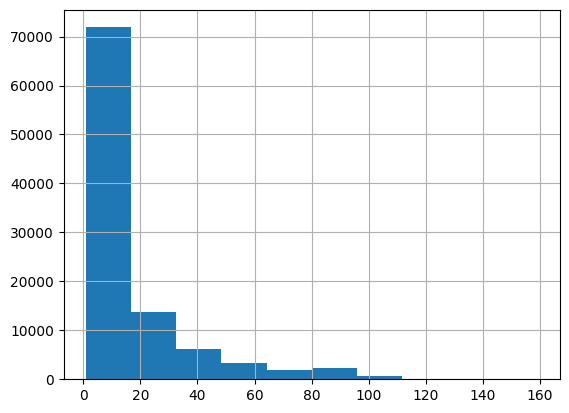

In [75]:
df["word_count"].hist()

**Finding:** most reviews are very short, 33% have 5 or fewer words. Fine for sentiment classification but a problem for topic modeling later, which needs enough text per review to embed meaningfully.

## Word Count Thresholds

In [76]:
for threshold in [5, 7, 10, 15, 20]:
    count = (df['word_count'] < threshold).sum()
    print(f"Under {threshold} words: {count} ({count/len(df)*100:.1f}%)")

Under 5 words: 39358 (39.4%)
Under 7 words: 48910 (48.9%)
Under 10 words: 58582 (58.6%)
Under 15 words: 68912 (68.9%)
Under 20 words: 75540 (75.5%)


**Decision:** 10 words is used as the minimum length for BERTopic input later, balancing enough negative reviews to cluster against not losing too much data.

# Sentiment Labeling

Initial sentiment labels are derived from star ratings as a starting point (1-2 stars Negative, 3 Neutral, 4-5 Positive), before DistilBERT later provides text-based labels that pick up nuance ratings miss.

In [77]:
def get_sentiment(score):
    if score <= 2:
        return "Negative"
    elif score == 3:
        return "Neutral"
    else:
        return "Positive"

df["sentiment"] = df["score"].apply(get_sentiment)
print(df["sentiment"].value_counts())

sentiment
Positive    66178
Negative    28255
Neutral      5565
Name: count, dtype: int64


**Distribution:** 66% Positive, 28% Negative, 6% Neutral, heavily imbalanced and skewed positive, as expected for app store reviews.

In [78]:
df_negative = df[df['sentiment'] == 'Negative']
df_bertopic = df_negative[df_negative['word_count'] >= 10]
print(f"Negative reviews with 10+ words: {len(df_bertopic)}")

Negative reviews with 10+ words: 19406


**Note:** 19,406 of these negative reviews have 10+ words, the pool BERTopic draws from before the later English filter narrows it further.

In [79]:
df.to_csv("spotify_reviews_processed.csv", index=False)

# DistilBERT Fine-Tuning

Fine-tuning was done on Google Colab using a T4 GPU, since training on CPU would take hours per epoch. Full training code lived in Colab, not in this notebook, only the resulting model and outputs are used here.

Initial 3-class labeling (Negative/Neutral/Positive) only reached 71% macro F1, limited by the small neutral class (5,565 samples) and its inherent ambiguity. Switching to binary classification (Negative/Positive), using all 28,255 negative reviews and an equal sample of positive reviews (56,510 total), raised macro F1 to 93.5%. Neutral predictions were never used downstream anyway, so the simpler binary setup was the right call.

**Validation results (held-out 20%):**  

              precision    recall  f1-score   support

    Negative       0.93      0.94      0.94      5651
    Positive       0.94      0.93      0.94      5651

    accuracy                           0.94     11302
    macro avg      0.94      0.94      0.94     11302
    weighted avg   0.94      0.94      0.94     11302

# Full Inference

The fine-tuned model is loaded and run on all 100,000 reviews to produce text-based sentiment predictions, not just the training sample.

In [80]:
if os.path.exists("spotify_reviews_with_sentiment.csv"):
    df = pd.read_csv("spotify_reviews_with_sentiment.csv")
    print("Loaded from CSV")
else:
    from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification
    import torch
    from tqdm import tqdm

    model_path = "distilbert_spotify_binary"
    tokenizer = DistilBertTokenizerFast.from_pretrained(model_path)
    model = DistilBertForSequenceClassification.from_pretrained(model_path)
    model.eval()

    def predict_sentiment(texts, batch_size=64):
        all_preds = []
        for i in tqdm(range(0, len(texts), batch_size)):
            batch = texts[i:i+batch_size]
            encodings = tokenizer(batch, truncation=True, padding=True, max_length=128, return_tensors="pt")
            with torch.no_grad():
                outputs = model(**encodings)
            preds = torch.argmax(outputs.logits, dim=-1).numpy()
            all_preds.extend(preds)
        return all_preds

    texts = df["content"].fillna("").tolist()
    predictions = predict_sentiment(texts)

    id2label = {0: "Negative", 1: "Positive"}
    df["predicted_sentiment"] = [id2label[p] for p in predictions]
    df.to_csv("spotify_reviews_with_sentiment.csv", index=False)
    print("Predicted and saved")

print(df["predicted_sentiment"].value_counts())

Loaded from CSV
predicted_sentiment
Positive    65526
Negative    34472
Name: count, dtype: int64


In [81]:
df.to_csv("spotify_reviews_with_sentiment.csv", index=False)

In [82]:
df_neg_pred = df[(df['predicted_sentiment'] == 'Negative') & (df['word_count'] >= 10)]
print(f"Negative reviews with 10+ words: {len(df_neg_pred)}")

Negative reviews with 10+ words: 23886


**Result:** 65,526 Positive, 34,472 Negative. Notably different from the star-rating labels since the model catches negativity in text that high star ratings can mask (e.g. "great app but too many ads" rated 5 stars).

# English Filtering

Despite scraping with `lang='en'`, some non-English reviews slipped through. Language filtering was done on Colab, using `langdetect` to keep only reviews detected as English before topic modeling, since mixed-language text degrades embedding-based clustering quality.

**Result:** 22,630 English reviews out of 23,886 negative reviews with 10+ words, about 5% were non-English and dropped.

# BERTopic Clustering

Topic modeling was also run on Colab, using `all-MiniLM-L6-v2` sentence embeddings rather than bag-of-words, so semantically similar complaints cluster together even without shared vocabulary. `min_topic_size=20` was chosen after testing `50` (only 5 topics, too coarse) and comparing against `20` (51 topics, appropriately granular without excessive noise).

**Result:** 51 topics discovered from 22,630 English negative reviews, with 32% falling into the noise cluster (topic -1), reviews too ambiguous or short to cluster meaningfully even after the 10-word filter.

In [83]:
df_topics = pd.read_csv('spotify_negative_with_topics.csv')
pd.DataFrame(df_topics['topic'].value_counts().sort_index()).head(10)

,count
topic,
-1,7254
0,5116
1,3753
2,1066
3,625
4,541
5,451
6,412
7,287


# Manual Topic Labeling

BERTopic's auto-generated labels (e.g. `1_ads_premium_song_app`) aren't usable in a dashboard. Each of the 51 topics is manually reviewed against its keywords and representative documents, then assigned a clean business label, or marked as noise if not actionable (e.g. non-English clusters, generic star-rating complaints).

In [84]:
topic_labels = {
    -1: "Noise",
    0: "General App Dissatisfaction",
    1: "Ads and Premium Upsell",
    2: "App Crashes and Bugs",
    3: "Widget Issues",
    4: "AI DJ and AI Artists",
    5: "Subscription and Payment Issues",
    6: "Shuffle Algorithm",
    7: "Noise",
    8: "Forced to Pay for Features",
    9: "Login and Account Issues",
    10: "Ads on Premium and Podcasts",
    11: "Premium Pricing and Ads",
    12: "Offline Mode Not Working",
    13: "Podcast Playback Issues",
    14: "Cannot Choose Songs on Free",
    15: "Noise",
    16: "False Offline Status",
    17: "App Slowness and Lag",
    18: "Audiobook Issues",
    19: "Playlist Management Issues",
    20: "Bluetooth and Car Integration",
    21: "Excessive Ads Frequency",
    22: "Missing or Wrong Lyrics",
    23: "Queue Management Issues",
    24: "Chromecast and Device Casting",
    25: "Skip Limit on Free",
    26: "Payment Not Processed",
    27: "Free Version Too Restricted",
    28: "App Getting Worse with Updates",
    29: "Noise",
    30: "Missing New Releases Feature",
    31: "Liked Songs Disappearing",
    32: "Noise",
    33: "Cannot Reorder Playlist",
    34: "Unwanted Videos on Home Screen",
    35: "Noise",
    36: "Noise",
    37: "App Force Closing in Background",
    38: "Poor Music Recommendations",
    39: "Noise",
    40: "Noise",
    41: "Subscription Cancellation Issues",
    42: "App Won't Load or Connect",
    43: "Price Increase Complaints",
    44: "Noise",
    45: "Missing Lossless Audio",
    46: "Noise",
    47: "Charged During Free Trial",
    48: "Search Function Issues",
    49: "Family and Duo Plan Issues",
    50: "Noise",
}

df_topics['topic_label'] = df_topics['topic'].map(topic_labels).fillna('Noise')
print(df_topics['topic_label'].value_counts().head(20))

topic_label
Noise                              7967
General App Dissatisfaction        5116
Ads and Premium Upsell             3753
App Crashes and Bugs               1066
Widget Issues                       625
AI DJ and AI Artists                541
Subscription and Payment Issues     451
Shuffle Algorithm                   412
Forced to Pay for Features          239
Login and Account Issues            222
Ads on Premium and Podcasts         170
Premium Pricing and Ads             169
Offline Mode Not Working            163
Podcast Playback Issues             152
Cannot Choose Songs on Free         138
False Offline Status                124
App Slowness and Lag                117
Audiobook Issues                     97
Playlist Management Issues           89
Bluetooth and Car Integration        89
Name: count, dtype: int64


**Top complaint themes:** General App Dissatisfaction, Ads and Premium Upsell, App Crashes and Bugs, Widget Issues, and AI DJ / AI Artists, together accounting for the majority of labeled negative reviews.

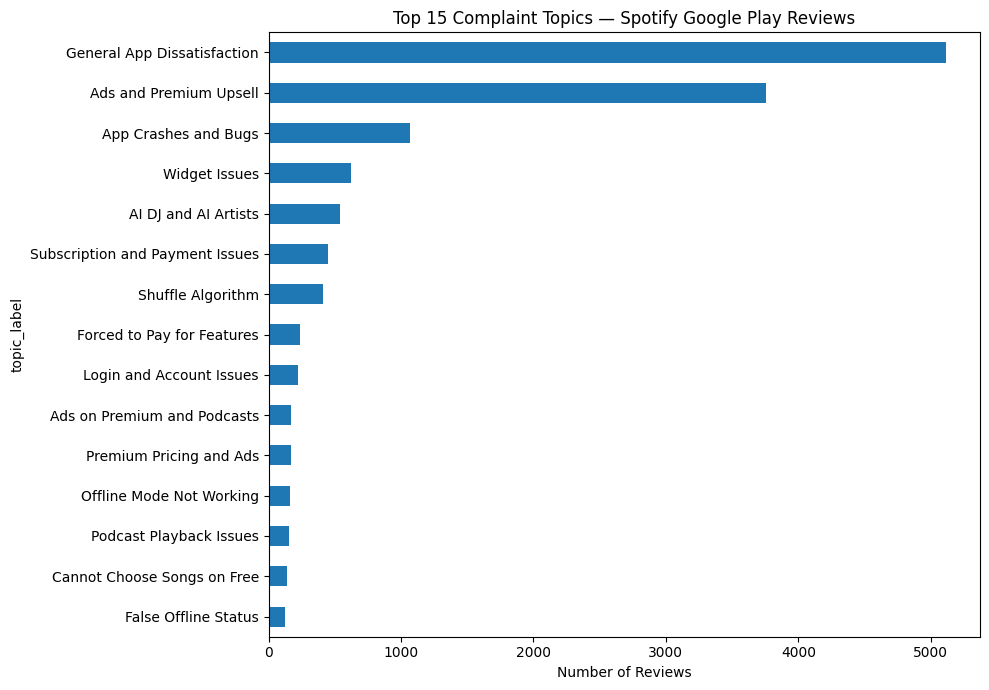

In [85]:
top_topics = df_topics[df_topics['topic_label'] != 'Noise']['topic_label'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 7))
top_topics.sort_values().plot(kind='barh', ax=ax, color='#1f77b4')
ax.set_xlabel("Number of Reviews")
ax.set_title("Top 15 Complaint Topics — Spotify Google Play Reviews")
plt.tight_layout()
plt.show()

# Temporal Trend Analysis

Negative sentiment rate is tracked across app versions with 100+ reviews, to catch releases that caused a spike in complaints.

In [86]:
# Versions with enough reviews
version_counts = df['appVersion'].value_counts()
valid_versions = version_counts[version_counts >= 100].index
df_temporal = df[df['appVersion'].isin(valid_versions)].copy()

# Negative rate per version
version_sentiment = df_temporal.groupby('appVersion').agg(total_reviews=('predicted_sentiment', 'count'), 
                                                          negative_reviews=('predicted_sentiment', lambda x: (x == 'Negative').sum())).reset_index()

version_sentiment['negative_rate'] = version_sentiment['negative_reviews'] / version_sentiment['total_reviews']
version_sentiment = version_sentiment.sort_values('appVersion')

print(version_sentiment.shape)
version_sentiment.head(10)

(31, 4)


,appVersion,total_reviews,negative_reviews,negative_rate
0,9.0.90.1229,113,48,0.424779
1,9.0.94.274,114,48,0.421053
2,9.0.96.826,103,48,0.466019
3,9.1.0.1147,165,100,0.606061
4,9.1.12.226,112,44,0.392857
5,9.1.14.864,196,68,0.346939
6,9.1.16.1450,283,97,0.342756
7,9.1.18.1504,254,75,0.295276
8,9.1.2.1253,115,54,0.469565
9,9.1.20.1452,574,144,0.250871


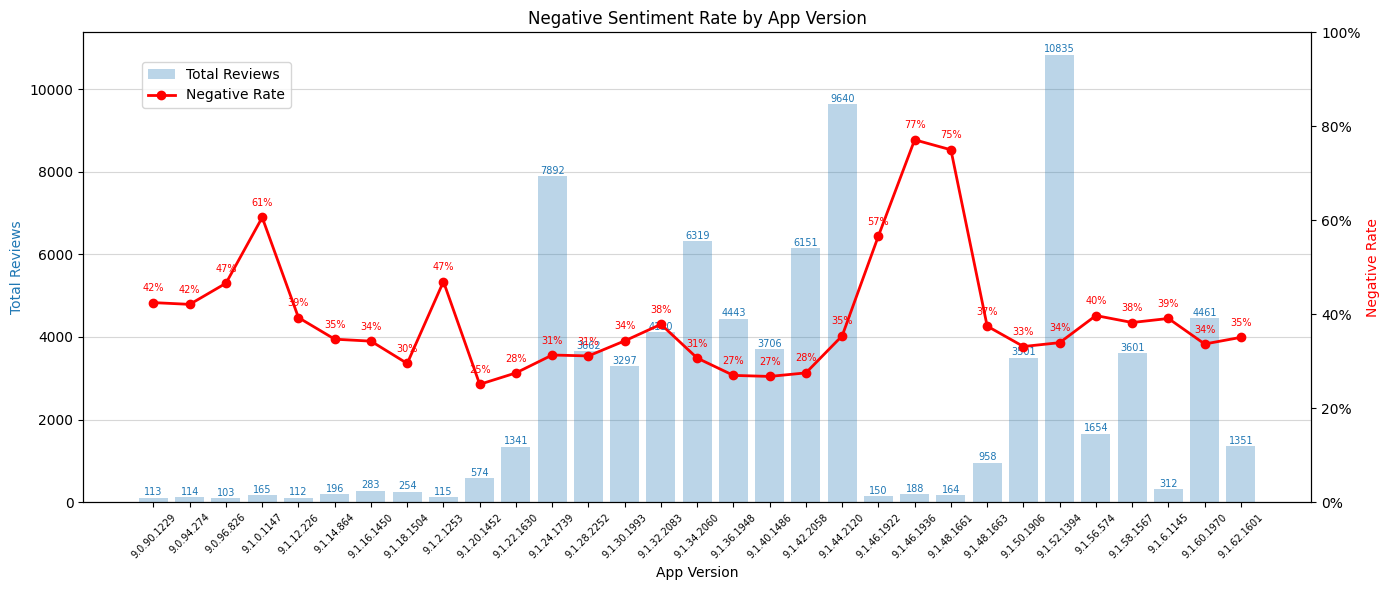

In [108]:
fig, ax1 = plt.subplots(figsize=(14, 6))

ax2 = ax1.twinx()

ax1.bar(range(len(version_sentiment)), version_sentiment['total_reviews'], alpha=0.3, color='#1f77b4', label='Total Reviews')
for i, v in enumerate(version_sentiment['total_reviews']):
    ax1.text(i, v + 10, str(v), ha='center', va='bottom', fontsize=7, color='#1f77b4')

ax2.plot(range(len(version_sentiment)), version_sentiment['negative_rate'], color='red', marker='o', linewidth=2, label='Negative Rate')
for i, v in enumerate(version_sentiment['negative_rate']):
    ax2.text(i, v + 0.02, f'{v:.0%}', ha='center', va='bottom', fontsize=7, color='red')

ax1.set_xticks(range(len(version_sentiment)))
ax1.set_xticklabels(version_sentiment['appVersion'], rotation=45, fontsize=7)
ax1.set_xlabel("App Version")
ax1.set_ylabel("Total Reviews", color='#1f77b4')
ax2.set_ylabel("Negative Rate", color='red')
ax2.set_ylim(0, 1)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

plt.title("Negative Sentiment Rate by App Version")
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
ax1.yaxis.grid(True, alpha=0.5, linestyle='-')
ax1.set_axisbelow(True)
plt.tight_layout()
plt.show()

**Finding:** versions 9.1.46 and 9.1.48 show the highest negative rates in the dataset (77% and 75%), both dominated by App Crashes and Bugs complaints, suggesting a regression introduced in 9.1.46 that persisted into 9.1.48.

## Version 9.1.46 and 9.1.48 Drill-Down

In [88]:
df_topics_version = df_topics[df_topics['appVersion'] == '9.1.46.1936']
df_topics_version['topic_label'].value_counts().head(5)

topic_label
General App Dissatisfaction    38
Noise                          37
App Crashes and Bugs           28
Ads and Premium Upsell          5
Login and Account Issues        4
Name: count, dtype: int64

In [89]:
df_topics_version2 = df_topics[df_topics['appVersion'] == '9.1.48.1661']
df_topics_version2['topic_label'].value_counts().head(5)

topic_label
Noise                          31
App Crashes and Bugs           27
General App Dissatisfaction    27
Ads and Premium Upsell          5
Login and Account Issues        4
Name: count, dtype: int64

# Priority Matrix

Each complaint topic is scored by frequency (50%), severity (30%, based on average star rating), and recent trend (20%, share of the 5 most recent versions), producing a ranked, actionable fix list rather than just a list of topics.

In [90]:
# Merging topic labels with df
df_topics_merged = df_topics[['content', 'appVersion', 'topic_label', 'topic_prob']].merge(df[['content', 'score', 'at']], on='content', how='left')

df_scored = df_topics_merged[df_topics_merged['topic_label'] != 'Noise'].copy()

# Metrics per topic
topic_stats = df_scored.groupby('topic_label').agg(review_count=('content', 'count'), avg_star_rating=('score', 'mean')).reset_index()

# Normalized frequency (0-1)
topic_stats['frequency_score'] = topic_stats['review_count'] / topic_stats['review_count'].max()

# Severity score: Lower star rating = higher severity (inverted and normalized)
topic_stats['severity_score'] = (5 - topic_stats['avg_star_rating']) / 4

recent_versions = version_sentiment.sort_values('appVersion').tail(5)['appVersion'].tolist()
df_recent = df_scored[df_scored['appVersion'].isin(recent_versions)]

recent_topic_neg = df_recent.groupby('topic_label').agg(recent_count=('content', 'count')).reset_index()

total_recent = len(df_recent)
recent_topic_neg['trend_score'] = recent_topic_neg['recent_count'] / total_recent

topic_stats = topic_stats.merge(recent_topic_neg[['topic_label', 'trend_score']], on='topic_label', how='left')
topic_stats['trend_score'] = topic_stats['trend_score'].fillna(0)

# Priority score
topic_stats['priority_score'] = (0.5 * topic_stats['frequency_score'] + 0.3 * topic_stats['severity_score'] + 0.2 * topic_stats['trend_score'])

# Rank
topic_stats = topic_stats.sort_values('priority_score', ascending=False).reset_index(drop=True)
topic_stats['rank'] = topic_stats.index + 1

topic_stats[['rank', 'topic_label', 'review_count', 'avg_star_rating', 'priority_score']].head(15)

,rank,topic_label,review_count,avg_star_rating,priority_score
0,1,General App Dissatisfaction,5118,1.681907,0.810872
1,2,Ads and Premium Upsell,3753,1.564615,0.663650
2,3,App Crashes and Bugs,1066,1.784240,0.368619
3,4,Widget Issues,625,1.793600,0.325149
4,5,Subscription and Payment Issues,451,1.379157,0.320870
5,6,AI DJ and AI Artists,541,1.571165,0.317361
6,7,Subscription Cancellation Issues,28,1.071429,0.297483
7,8,Forced to Pay for Features,239,1.543933,0.285282
8,9,Shuffle Algorithm,412,1.832524,0.282428
9,10,Login and Account Issues,222,1.639640,0.276129


**Top priority:** General App Dissatisfaction and Ads and Premium Upsell rank highest by volume and severity combined. Several low-volume topics (e.g. Subscription Cancellation Issues, App Won't Load) also rank surprisingly high due to being disproportionately concentrated in recent versions.

In [91]:
actions = {
    "General App Dissatisfaction": "Conduct user interviews to identify root causes of broad dissatisfaction",
    "Ads and Premium Upsell": "Reduce ad frequency for free users and clarify premium value proposition",
    "App Crashes and Bugs": "Prioritize crash reporting and fix regression introduced in version 9.1.46",
    "Widget Issues": "Restore old widget functionality and fix new widget display issues",
    "Subscription and Payment Issues": "Improve payment flow and refund process transparency",
    "AI DJ and AI Artists": "Add opt-out option for AI-generated content in user settings",
    "Shuffle Algorithm": "Revert smart shuffle or add option to use true random shuffle",
    "Forced to Pay for Features": "Reconsider which features are locked behind premium",
    "Login and Account Issues": "Fix persistent logout bug and improve account recovery flow",
    "Ads on Premium and Podcasts": "Investigate ad serving on premium accounts and fix podcast ad injection",
}

topic_stats['recommended_action'] = topic_stats['topic_label'].map(actions).fillna("Investigate and monitor")

topic_stats[['rank', 'topic_label', 'review_count', 'avg_star_rating', 'priority_score', 'recommended_action']].head(10)

,rank,topic_label,review_count,avg_star_rating,priority_score,recommended_action
0,1,General App Dissatisfaction,5118,1.681907,0.810872,Conduct user interviews to identify root cause...
1,2,Ads and Premium Upsell,3753,1.564615,0.663650,Reduce ad frequency for free users and clarify...
2,3,App Crashes and Bugs,1066,1.784240,0.368619,Prioritize crash reporting and fix regression ...
3,4,Widget Issues,625,1.793600,0.325149,Restore old widget functionality and fix new w...
4,5,Subscription and Payment Issues,451,1.379157,0.320870,Improve payment flow and refund process transp...
5,6,AI DJ and AI Artists,541,1.571165,0.317361,Add opt-out option for AI-generated content in...
6,7,Subscription Cancellation Issues,28,1.071429,0.297483,Investigate and monitor
7,8,Forced to Pay for Features,239,1.543933,0.285282,Reconsider which features are locked behind pr...
8,9,Shuffle Algorithm,412,1.832524,0.282428,Revert smart shuffle or add option to use true...
9,10,Login and Account Issues,222,1.639640,0.276129,Fix persistent logout bug and improve account ...


# Model Confidence

Prediction confidence (softmax probability of the predicted class) was computed on Colab GPU alongside a rerun of inference, since it wasn't saved the first time.

In [92]:
df_conf = pd.read_csv('spotify_reviews_with_confidence.csv')
df_conf_light = df_conf[['predicted_sentiment', 'confidence']].copy()
df_conf_light.to_csv('spotify_confidence_light.csv', index=False)

In [93]:
print(df_conf['confidence'].min())
print(df_conf['confidence'].describe())

0.5004734
count    99998.000000
mean         0.962096
std          0.069597
min          0.500473
25%          0.973530
50%          0.984772
75%          0.988909
max          0.997117
Name: confidence, dtype: float64


**Result:** average confidence 96.2%, with 90.5% of predictions above 90% confidence and only 1% below 60%. The model is highly decisive rather than hedging, consistent with its 93.5% validation macro F1.

# Saving Artifacts for Deployment

Final processed dataframes are saved here, then split into lighter versions later for the Streamlit app, since the full files caused memory crashes on Streamlit Community Cloud's free tier.

## Deployment CSVs

In [94]:
df.to_csv('spotify_reviews_final.csv', index=False)
df_topics.to_csv('spotify_topics_final.csv', index=False)
topic_stats.to_csv('spotify_priority_matrix.csv', index=False)
version_sentiment.to_csv('spotify_version_sentiment.csv', index=False)

In [95]:
print("df:", df.columns.tolist())
print("df_topics:", df_topics.columns.tolist())
print("topic_stats:", topic_stats.columns.tolist())
print("version_sentiment:", version_sentiment.columns.tolist())

df: ['userName', 'content', 'score', 'thumbsUpCount', 'at', 'appVersion', 'sentiment', 'month', 'word_count', 'predicted_sentiment']
df_topics: ['userName', 'content', 'score', 'thumbsUpCount', 'at', 'appVersion', 'sentiment', 'month', 'word_count', 'predicted_sentiment', 'is_english', 'topic', 'topic_prob', 'topic_label']
topic_stats: ['topic_label', 'review_count', 'avg_star_rating', 'frequency_score', 'severity_score', 'trend_score', 'priority_score', 'rank', 'recommended_action']
version_sentiment: ['appVersion', 'total_reviews', 'negative_reviews', 'negative_rate']


In [96]:
df_light = df[['score', 'month', 'word_count', 'predicted_sentiment']].copy()
df_light.to_csv('spotify_reviews_light.csv', index=False)

In [97]:
df_topics_light = df_topics[['content', 'score', 'appVersion', 'topic_label']].copy()
df_topics_light.to_csv('spotify_topics_light.csv', index=False)

In [98]:
version_topic_agg = df_topics[df_topics['topic_label'] != 'Noise'].groupby(['appVersion', 'topic_label']).size().reset_index(name='count')

version_topic_agg.to_csv('spotify_version_topic_agg.csv', index=False)

In [110]:
df_topics_meta = df_topics[['score', 'appVersion', 'topic_label']].copy()
df_topics_meta.to_csv('spotify_topics_meta.csv', index=False)

df_topics_sample = df_topics.groupby('topic_label', group_keys=False)[['content', 'score', 'appVersion']].apply(lambda x: x.sample(min(20, len(x)), random_state=36))

df_topics_sample['topic_label'] = df_topics.loc[df_topics_sample.index, 'topic_label']

df_topics_sample.to_csv('spotify_topics_sample.csv', index=False)

print(df_topics_meta.shape)
print(df_topics_sample.shape)

(22630, 3)
(820, 4)


## Misclassification Analysis

In [100]:
df_mismatch = df[df['sentiment'] != df['predicted_sentiment']].copy()

df_mismatch_clear = df_mismatch[df_mismatch['sentiment'].isin(['Negative', 'Positive'])]

print(df_mismatch_clear.shape)
print(df_mismatch_clear.groupby(['sentiment', 'predicted_sentiment']).size())

(4573, 10)
sentiment  predicted_sentiment
Negative   Positive               1019
Positive   Negative               3554
dtype: int64


In [101]:
df_mismatch_clear[['content', 'score', 'sentiment', 'predicted_sentiment', 'appVersion']].to_csv('spotify_mismatches.csv', index=False)

## Embedding Coordinates

In [102]:
umap_df = pd.read_csv('spotify_umap_coords.csv')
umap_df['topic_label'] = umap_df['topic'].map(topic_labels).fillna('Noise')

umap_df[['content', 'topic_label', 'umap_x', 'umap_y', 'score']].to_csv('spotify_umap_final.csv', index=False)
print(umap_df.shape)

(22630, 16)


# Summary

**Pipeline:** scrape reviews, derive star-rating sentiment labels, fine-tune DistilBERT for binary classification, run inference on all 100K reviews, filter to English negatives, cluster with BERTopic, manually label topics, track sentiment by version, score topics into a priority matrix.

**Key results:**
- DistilBERT macro F1: 0.935
- 51 complaint topics discovered, manually labeled into business-readable themes
- Versions 9.1.46/9.1.48 identified as a crash regression via temporal analysis
- Priority matrix translates NLP output into a ranked, actionable fix list

**Known limitations:**
- 35% of negative reviews fall into the noise cluster and aren't represented in the priority matrix
- 16.4% of reviews lack version metadata and are excluded from temporal analysis
- In-app review search operates on an 820-review sample, not the full corpus, for deployment memory efficiency

**Deployment:** live at [spotify-review-intelligence.streamlit.app](https://spotify-review-intelligence.streamlit.app), with 7 pages covering overview, complaint intelligence, version trends, priority matrix, misclassification analysis, pipeline overview, and embedding visualization.